# Введение в GCNN. Message passing framework

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Курс "Машинное обучение на графах", Лекции 4-5 "Графовые нейронные сети"
* Документация:
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.triangles.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.distance_measures.eccentricity.html#networkx.algorithms.distance_measures.eccentricity
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.eigenvector_centrality.html

* Дополнительные источники:
    * https://tkipf.github.io/graph-convolutional-networks/

## Вопросы для совместного обсуждения

1\. Обсудите общие принципы организации вычислений в MPF и его использование для построения графовых сверточных нейронных сетей. 

## Задачи для самостоятельного решения

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Callable, Optional

<p class="task" id="1"></p>

1\. Загрузите граф из файла `karate.graphml`. Визуализируйте граф, раскрасив в цвета классов (атрибут `label` у узлов). 

Получите невзвешенную матрицу смежности $\mathbf{A}$ в виде тензора `torch` и тензор меток для каждого узла. Выведите полученные тензоры на экран.

- [ ] Проверено на семинаре

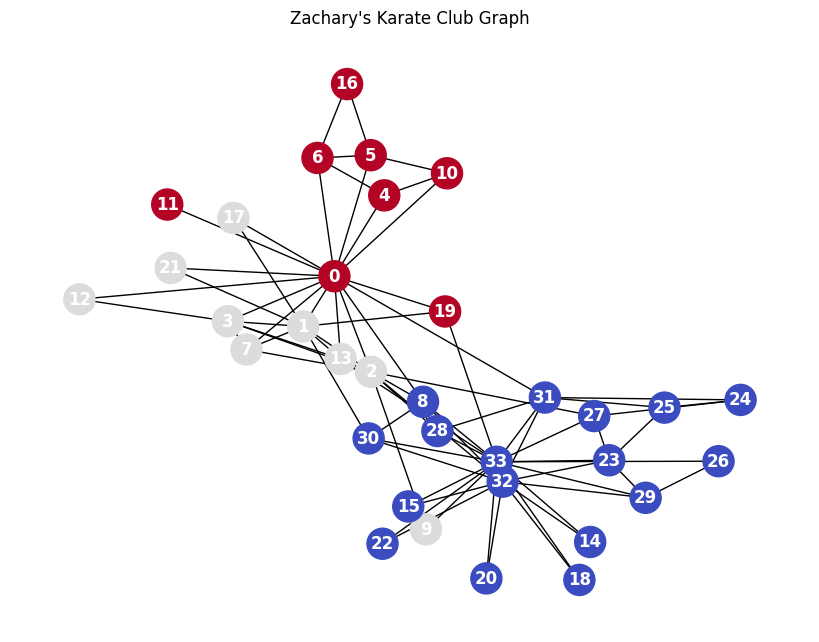

In [3]:
graph_path = "data/karate.graphml"
G = nx.read_graphml(graph_path)
labels = [int(G.nodes[node]['label']) for node in G.nodes()]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos, 
    node_color=labels, 
    cmap=plt.cm.coolwarm, 
    with_labels=True, 
    node_size=500,
    font_color='white',
    font_weight='bold'
)
plt.title("Zachary's Karate Club Graph")
plt.show()

In [ ]:
A_np = nx.to_numpy_array(G)
A = torch.tensor(A_np, dtype=torch.float32) # [N, N]
y = torch.tensor(labels, dtype=torch.long) # [N]

print("Форма матрицы смежности A:", A.shape)
print("Матрица смежности A (фрагмент 5x5):\n", A[:5, :5])
print("\nФорма тензора меток y:", y.shape)
print("Метки y:\n", y)

Форма матрицы смежности A: torch.Size([34, 34])
Матрица смежности A (фрагмент 5x5):
 tensor([[0., 4., 5., 3., 3.],
        [4., 0., 6., 3., 0.],
        [5., 6., 0., 3., 0.],
        [3., 3., 3., 0., 0.],
        [3., 0., 0., 0., 0.]])

Форма тензора меток y: torch.Size([34])
Метки y:
 tensor([2, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 2, 1, 1, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


<p class="task" id="2"></p>

2\. Найдите стохастическую матрицу $\hat{\mathbf{A}}$. 

$$\hat{\mathbf{A}} =\mathbf{D}^{-1}\mathbf{A}$$


Сгенерируйте тензор $\mathbf{X}$ размера `Nx5` с признаками узлов, используя `torch.rand`. Выполните один шаг рассылки сообщений при помощи матричного умножения.

$$\hat{\mathbf{X}} =\hat{\mathbf{A}}\mathbf{X}$$

Выполните этот же шаг рассылки сообщений, явно проитерировавшись по узлам графа и усреднив атрибуты соседей. Сравните два полученных тензора и покажите, что они равны.

- [ ] Проверено на семинаре

In [7]:
A_unweighted = (A > 0).float()

N = A_unweighted.shape[0]
degrees = A_unweighted.sum(dim=1).clamp(min=1) # [N]
D_inv = torch.diag(1.0 / degrees)
A_hat = torch.matmul(D_inv, A_unweighted)
torch.manual_seed(42)
X = torch.rand(N, 5) # [N, 5]
X_hat_matrix = torch.matmul(A_hat, X)
X_hat_iter = torch.zeros_like(X)

for i in range(N):
    neighbors_idx = torch.where(A_unweighted[i] > 0)[0]
    if len(neighbors_idx) > 0:
        X_hat_iter[i] = X[neighbors_idx].mean(dim=0)

is_equal = torch.allclose(X_hat_matrix, X_hat_iter, atol=1e-6)

print(f"Матричное умножение и итеративный подход дают одинаковый результат: {is_equal}")
print("\nРезультат через матричное умножение (первые 3 узла):\n", X_hat_matrix[:3])

Матричное умножение и итеративный подход дают одинаковый результат: True

Результат через матричное умножение (первые 3 узла):
 tensor([[0.4653, 0.5112, 0.5027, 0.5540, 0.3629],
        [0.5389, 0.6657, 0.4496, 0.3676, 0.4565],
        [0.5991, 0.5487, 0.5596, 0.5459, 0.4194]])


<p class="task" id="3"></p>

3\. Опишите слой `GCNLayer` графовой сверточной нейронной сети. Создайте слой с `n_outputs=3` и пропустите через этот слой матрицу смежности графа и тензор признаков  $\mathbf{X} = \mathbf{E}$. Выведите форму полученного тензора на экран.

- [ ] Проверено на семинаре

In [ ]:
class GCNLayer(nn.Module):
    def __init__(self, n_inputs: int, n_outputs: int, activation: Optional[Callable] = None):
        super().__init__()
        
        W = torch.empty(n_inputs, n_outputs, dtype=torch.float32)
        nn.init.xavier_uniform_(W)
        self.W = nn.Parameter(W, requires_grad=True)
        
        self.activation = activation
        
    def normalize_matrix(self, A: torch.Tensor) -> torch.Tensor:
        """
        A - исходная матрица смежности графа [N, N]
        Возвращает: D^{-1}(A + I) [N, N]
        """
        N = A.shape[0]
        A_tilde = A + torch.eye(N, device=A.device)
        degrees = A_tilde.sum(dim=1).clamp(min=1e-5)
        A_hat = A_tilde / degrees.unsqueeze(1)
        return A_hat
    
    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        """
        A - исходная матрица смежности графа [N, N]
        X - матрица признаков узлов [N, F_in]
        """
        A_hat = self.normalize_matrix(A) # [N, N]
        M = torch.matmul(A_hat, X)
        H = torch.matmul(M, self.W)
        
        if self.activation is not None:
            H = self.activation(H)
            
        return H

In [ ]:
N = A.shape[0]
X_identity = torch.eye(N)

layer = GCNLayer(n_inputs=N, n_outputs=3, activation=torch.tanh)

output_tensor = layer(A, X_identity)

print("Входная размерность X:", X_identity.shape)
print("Выходная размерность тензора:", output_tensor.shape)

Входная размерность X: torch.Size([34, 34])
Выходная размерность тензора: torch.Size([34, 3])


<p class="task" id="4"></p>

4\. Используя графовую сверточную нейронную сеть, решите задачу классификации узлов. Создайте модель, состоящую из двух последовательно идущих слоев `GCNLayer`. Первый слой имеет 2 нейрона и гиперболический тангенс в качестве функции активации. Количество нейронов во втором слое определяется количеством классов в задаче. Настройте модель (в качестве признаков узлов используйте единичную матрицу $\mathbf{X} = \mathbf{E}$). 

После завершения процесса обучения пропустите данные через первый слой и визуализируйте граф, используя полученные векторные представления в качестве координат. Раскрасьте узлы в цвет соответствующих классов.

- [ ] Проверено на семинаре

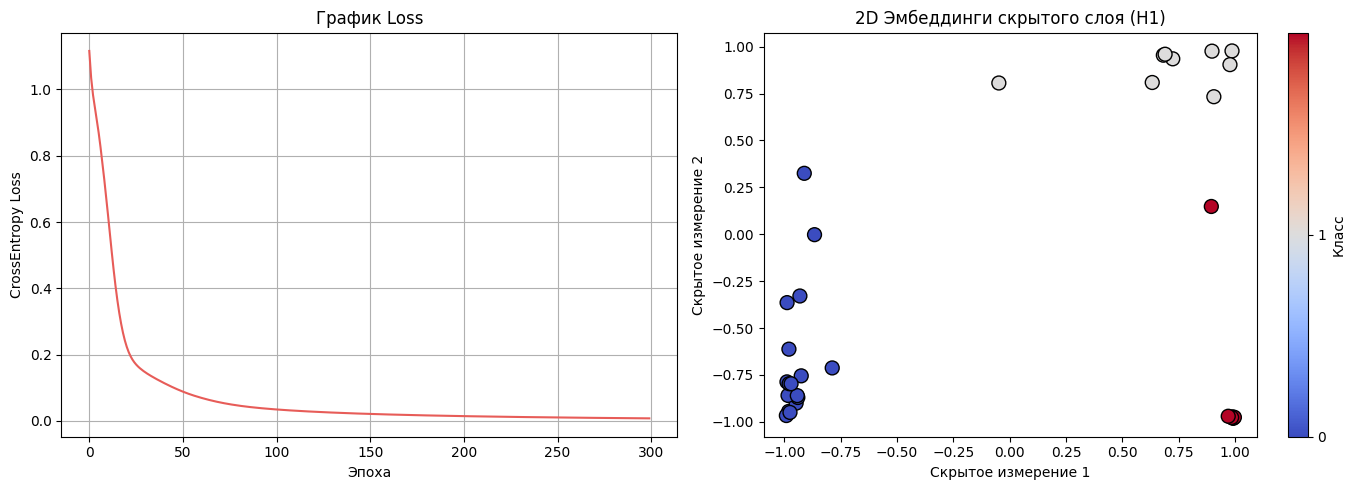

In [ ]:
class GCNModel(nn.Module):
    def __init__(self, n_inputs: int, n_hidden: int, n_classes: int):
        super().__init__()
        self.layer1 = GCNLayer(n_inputs, n_hidden, activation=torch.tanh)
        self.layer2 = GCNLayer(n_hidden, n_classes, activation=None)
        
    def forward(self, A: torch.Tensor, X: torch.Tensor):
        H1 = self.layer1(A, X)
        out = self.layer2(A, H1)
        return out, H1

n_inputs = N
n_hidden = 2
n_classes = len(torch.unique(y))
torch.manual_seed(42)
model_identity = GCNModel(n_inputs, n_hidden, n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_identity.parameters(), lr=0.1)

epochs = 300
loss_history =[]

for epoch in range(epochs):
    model_identity.train()
    optimizer.zero_grad()
    
    logits, _ = model_identity(A, X_identity)
    
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())

model_identity.eval()
with torch.no_grad():
    _, embeddings = model_identity(A, X_identity) # [N, 2]
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history, color='#e75c58')
axes[0].set_title('График Loss')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].grid(True)

emb_np = embeddings.numpy()
scatter = axes[1].scatter(emb_np[:, 0], emb_np[:, 1], c=y.numpy(), cmap=plt.cm.coolwarm, s=100, edgecolors='k')
axes[1].set_title('2D Эмбеддинги скрытого слоя (H1)')
axes[1].set_xlabel('Скрытое измерение 1')
axes[1].set_ylabel('Скрытое измерение 2')
plt.colorbar(scatter, ax=axes[1], ticks=[0, 1], label='Класс')

plt.tight_layout()
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение предыдущей задачи, используя в качестве признаков $\mathbf{X}$ следующие характеристики узлов (каждый узел описывается четырьмя характеристиками): 
* количество треугольников, в которые входит узел;
* степень узла;
* эксцентриситет узла;
* центральность по собственному вектору для узла.

Для ускорения процесса обучения стандартизуйте тензор признаков.


- [ ] Проверено на семинаре

Размерность новой матрицы признаков: torch.Size([34, 4])
Фрагмент стандартизированных признаков (первые 3 узла):
 tensor([[ 2.9728,  2.9428, -1.4355,  2.3064],
        [ 1.7014,  1.1377, -1.4355,  1.3187],
        [ 1.4895,  1.3956, -1.4355,  1.8840]])


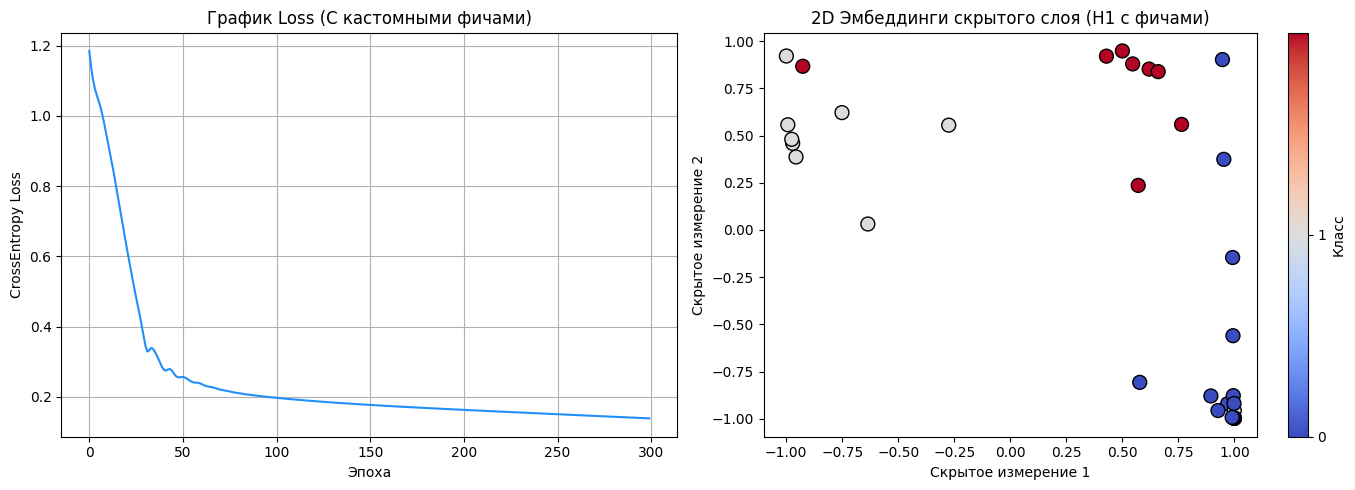

In [16]:
triangles_dict = nx.triangles(G)
nodes_list = list(G.nodes())
triangles = [triangles_dict[node] for node in nodes_list]
degrees = [G.degree(node) for node in nodes_list]
eccentricity_dict = nx.eccentricity(G)
eccentricity =[eccentricity_dict[node] for node in nodes_list]
eigen_dict = nx.eigenvector_centrality(G, max_iter=1000)
eigen_centrality = [eigen_dict[node] for node in nodes_list]
X_features_np = torch.tensor([triangles, degrees, eccentricity, eigen_centrality], dtype=torch.float32).T
X_mean = X_features_np.mean(dim=0, keepdim=True)
X_std = X_features_np.std(dim=0, keepdim=True)
X_features = (X_features_np - X_mean) / X_std # [N, 4]

print("Размерность новой матрицы признаков:", X_features.shape)
print("Фрагмент стандартизированных признаков (первые 3 узла):\n", X_features[:3])

n_inputs_feat = 4
model_features = GCNModel(n_inputs_feat, n_hidden, n_classes)
optimizer_feat = optim.Adam(model_features.parameters(), lr=0.1)

loss_history_feat =[]

for epoch in range(epochs):
    model_features.train()
    optimizer_feat.zero_grad()
    
    logits, _ = model_features(A, X_features)
    loss = criterion(logits, y)
    
    loss.backward()
    optimizer_feat.step()
    
    loss_history_feat.append(loss.item())

model_features.eval()
with torch.no_grad():
    _, embeddings_feat = model_features(A, X_features)
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history_feat, color='#208ffb')
axes[0].set_title('График Loss (С кастомными фичами)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].grid(True)

emb_feat_np = embeddings_feat.numpy()
scatter = axes[1].scatter(emb_feat_np[:, 0], emb_feat_np[:, 1], c=y.numpy(), cmap=plt.cm.coolwarm, s=100, edgecolors='k')
axes[1].set_title('2D Эмбеддинги скрытого слоя (H1 с фичами)')
axes[1].set_xlabel('Скрытое измерение 1')
axes[1].set_ylabel('Скрытое измерение 2')
plt.colorbar(scatter, ax=axes[1], ticks=[0, 1], label='Класс')

plt.tight_layout()
plt.show()

Не то, чтобы стало лучше...